In [ ]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ─────────────────────── Paths ───────────────────────
PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
STATISTICS_DIR = PROJECT_ROOT / "statistics"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "nested_cv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────── Plotting style (match thesis) ───────────────────────
PLOT_STYLE = {
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titleweight": "normal",
    "axes.titlepad": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}
sns.set_theme(context="notebook", style="whitegrid", palette="deep")

# Color palette matching nested_cv_analysis
MODEL_COLORS = {
    "GBLUP": "#bdbdbd",  # grey
    "MLP": "#5a7bc4",    # lighter blue
    "GCN": "#c98654",     # lighter orange
    "GraphSAGE": "#4d9c6b",  # lighter green
}

# ─────────────────────── Label maps ───────────────────────
PHENOTYPE_LABELS = {
    "thr_tarsus": "Tarsus length",
    "body_mass": "Body mass",
    "thr_wing": "Wing length",
}
SCENARIO_LABELS = {"across": "Across", "within": "Within"}
MODEL_LABELS = {"gcn": "GCN", "graphsage": "GraphSAGE"}

# Island code → name mapping (for LOIO)
ISLAND_NAMES = {
    20: "Nesøy", 22: "Myken", 23: "Træna", 24: "Selvær",
    26: "Gjerøy", 27: "Hestmannøy", 28: "Indre Kvarøy",
    33: "Onøy/Lurøy", 34: "Lovund", 35: "Sleneset", 38: "Aldra",
}

print(f"Results dir: {RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Results dir: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\outputs\nested_cv
Figures dir: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures


## 1. Load all nested CV result JSONs

In [498]:
def load_nested_cv_results(base_dir: Path) -> pd.DataFrame:
    """Parse all nested CV JSONs into a tidy DataFrame with one row per fold."""
    rows: List[Dict[str, Any]] = []
    for phenotype_dir in sorted(base_dir.glob("*")):
        if not phenotype_dir.is_dir():
            continue
        phenotype = phenotype_dir.name
        if phenotype not in PHENOTYPE_LABELS:
            continue
        for scenario in ("loio", "within"):
            scenario_dir = phenotype_dir / scenario
            if not scenario_dir.exists():
                continue
            for json_path in sorted(scenario_dir.glob("*.json")):
                model_key = json_path.stem.replace("_results", "")
                # Skip non-graph models for this analysis
                if "gcn" not in model_key and "sage" not in model_key:
                    continue
                # Determine model type
                if "gcn" in model_key:
                    model_type = "gcn"
                elif "sage" in model_key:
                    model_type = "sage"
                else:
                    continue
                try:
                    with open(json_path) as fp:
                        data = json.load(fp)
                except Exception as e:
                    print(f"Failed to load {json_path}: {e}")
                    continue
                
                outer_corr = data.get("outer_test_corr") or []
                best_params = data.get("best_params_per_fold") or []
                
                for fold_idx, fold_info in enumerate(best_params):
                    params = fold_info.get("best_params") or fold_info.get("params") or {}
                    fold_num = fold_info.get("fold", fold_idx + 1)
                    corr = outer_corr[fold_idx] if fold_idx < len(outer_corr) else np.nan
                    
                    row = {
                        "phenotype": phenotype,
                        "phenotype_label": PHENOTYPE_LABELS.get(phenotype, phenotype),
                        "scenario": scenario,
                        "scenario_label": SCENARIO_LABELS.get(scenario, scenario),
                        "model_type": model_type,
                        "model_label": MODEL_LABELS.get(model_type, model_type),
                        "model_key": model_key,
                        "fold": fold_num,
                        "test_correlation": corr,
                        # Graph params
                        "graph_mode": params.get("graph_mode"),
                        "cutoff": params.get("cutoff"),
                        "knn_k": params.get("knn_k"),
                        "weighted_edges": params.get("weighted_edges"),
                        "use_snp_selection": params.get("use_snp_selection", False),
                        "num_snps": params.get("num_snps"),
                    }
                    rows.append(row)
    return pd.DataFrame(rows)


df = load_nested_cv_results(RESULTS_DIR)
print(f"Loaded {len(df)} fold records")
print(f"Phenotypes: {df['phenotype'].unique().tolist()}")
print(f"Scenarios: {df['scenario'].unique().tolist()}")
print(f"Models: {df['model_key'].unique().tolist()}")
df.head()

Loaded 255 fold records
Phenotypes: ['body_mass', 'thr_tarsus', 'thr_wing']
Scenarios: ['loio', 'within']
Models: ['ens_sage', 'gcn_inductive', 'gcn', 'sage_inductive', 'sage']


,phenotype,phenotype_label,scenario,scenario_label,model_type,model_label,model_key,fold,test_correlation,graph_mode,cutoff,knn_k,weighted_edges,use_snp_selection,num_snps
0,body_mass,Body mass,loio,loio,sage,sage,ens_sage,1,0.228669,None,NaN,NaN,None,False,NaN
1,body_mass,Body mass,loio,loio,sage,sage,ens_sage,2,0.453528,None,NaN,NaN,None,False,NaN
2,body_mass,Body mass,loio,loio,sage,sage,ens_sage,3,0.158698,None,NaN,NaN,None,False,NaN
3,body_mass,Body mass,loio,loio,sage,sage,ens_sage,4,0.215068,None,NaN,NaN,None,False,NaN
4,body_mass,Body mass,loio,loio,sage,sage,ens_sage,5,0.173397,None,NaN,NaN,None,False,NaN


## 2. Proportion: knn-k vs cutoff selection

In [499]:
# Count how often knn vs cutoff was chosen
graph_mode_counts = df.groupby(["model_label", "scenario_label", "graph_mode"]).size().unstack(fill_value=0)
graph_mode_proportions = graph_mode_counts.div(graph_mode_counts.sum(axis=1), axis=0)

print("=== Graph mode counts ===")
display(graph_mode_counts)

print("\n=== Graph mode proportions ===")
display(graph_mode_proportions.round(3))

# Summary across all
total_counts = df["graph_mode"].value_counts()
total_props = total_counts / total_counts.sum()
print(f"\n=== Overall proportions ===")
for mode, prop in total_props.items():
    print(f"  {mode}: {prop:.1%} ({total_counts[mode]} folds)")

=== Graph mode counts ===


graph_mode                  cutoff  knn
model_label scenario_label             
GCN         Within              27    3
            loio                58    8
sage        Within              48   12
            loio                41   25


=== Graph mode proportions ===


graph_mode                  cutoff    knn
model_label scenario_label               
GCN         Within           0.900  0.100
            loio             0.879  0.121
sage        Within           0.800  0.200
            loio             0.621  0.379


=== Overall proportions ===
  cutoff: 78.4% (174 folds)
  knn: 21.6% (48 folds)


Saved figure to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures\graph_stats_3x2_boxplot.pdf


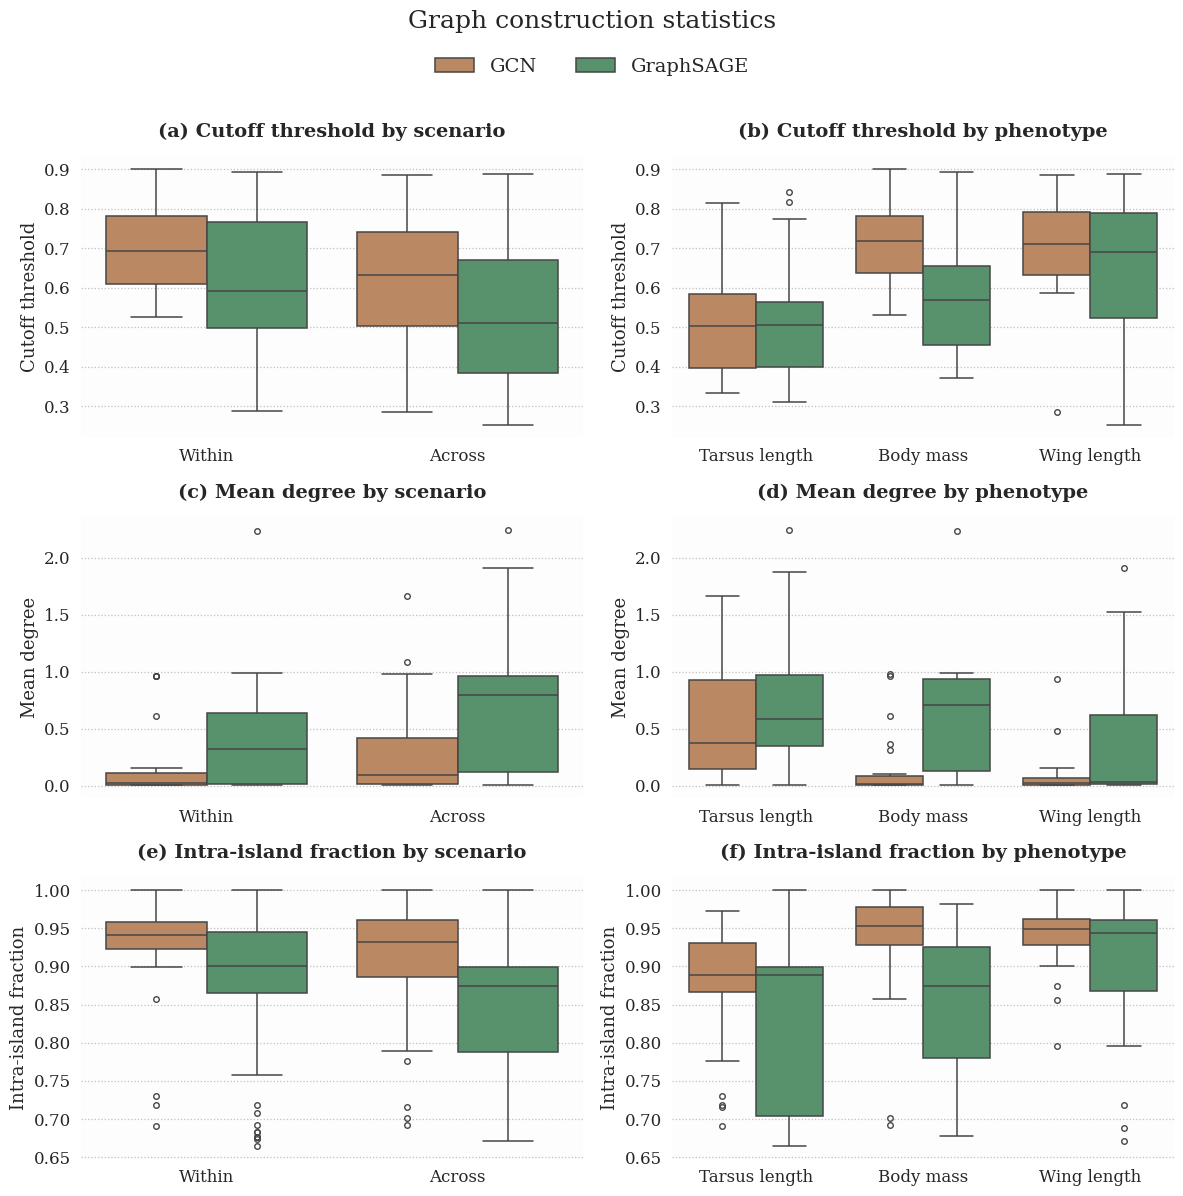

In [500]:
# Graph construction statistics: 3×2 figure (rows = metrics, cols = scenario/phenotype)
# Similar layout to SNP selection figure: first column = by scenario, second column = by phenotype
if not graph_summary.empty:
    plot_df = graph_summary.copy()
    plot_df = plot_df.dropna(subset=["mean_degree", "intra_island_fraction"])
    
    # Order for consistent display
    phenotype_order = ["Tarsus length", "Body mass", "Wing length"]
    scenario_order = ["Within", "Across"]  # Match SNP selection figure order
    model_order = ["GCN", "GraphSAGE"]
    
    metrics = [
        ("threshold", "Cutoff threshold"),
        ("mean_degree", "Mean degree"),
        ("intra_island_fraction", "Intra-island fraction"),
    ]
    
    model_palette = {"GCN": MODEL_COLORS["GCN"], "GraphSAGE": MODEL_COLORS["GraphSAGE"]}
    
    with plt.rc_context(PLOT_STYLE):
        fig, axes = plt.subplots(3, 2, figsize=(12, 12))
        
        panel_labels = [
            ["(a)", "(b)"],
            ["(c)", "(d)"],
            ["(e)", "(f)"],
        ]
        
        for row_idx, (metric_col, metric_label) in enumerate(metrics):
            # Filter data for this metric
            metric_df = plot_df.dropna(subset=[metric_col])
            
            # ─────────────────────── Left column: by scenario ───────────────────────
            ax_left = axes[row_idx, 0]
            if not metric_df.empty:
                sns.boxplot(
                    data=metric_df,
                    x="scenario_label",
                    y=metric_col,
                    hue="model_label",
                    hue_order=model_order,
                    order=scenario_order,
                    palette=model_palette,
                    ax=ax_left,
                    linewidth=1.1,
                    fliersize=4.0,
                )
            
            ax_left.set_xlabel("", fontsize=13)
            ax_left.set_ylabel(metric_label, fontsize=13)
            ax_left.set_title(f"{panel_labels[row_idx][0]} {metric_label} by scenario", fontsize=14, fontweight="semibold")
            ax_left.set_facecolor("#fdfdfd")
            ax_left.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
            ax_left.tick_params(axis="x", labelsize=12, length=4)
            ax_left.tick_params(axis="y", labelsize=12, length=4)
            if ax_left.legend_:
                ax_left.legend_.remove()
            for spine in ax_left.spines.values():
                spine.set_visible(False)
            
            # ─────────────────────── Right column: by phenotype ───────────────────────
            ax_right = axes[row_idx, 1]
            if not metric_df.empty:
                sns.boxplot(
                    data=metric_df,
                    x="phenotype_label",
                    y=metric_col,
                    hue="model_label",
                    hue_order=model_order,
                    order=phenotype_order,
                    palette=model_palette,
                    ax=ax_right,
                    linewidth=1.1,
                    fliersize=4.0,
                )
            
            ax_right.set_xlabel("", fontsize=13)
            ax_right.set_ylabel(metric_label, fontsize=13)
            ax_right.set_title(f"{panel_labels[row_idx][1]} {metric_label} by phenotype", fontsize=14, fontweight="semibold")
            ax_right.set_facecolor("#fdfdfd")
            ax_right.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
            ax_right.tick_params(axis="x", labelsize=12, length=4)
            ax_right.tick_params(axis="y", labelsize=12, length=4)
            if ax_right.legend_:
                ax_right.legend_.remove()
            for spine in ax_right.spines.values():
                spine.set_visible(False)
        
        # Add shared legend below title
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(
                handles, labels,
                title="",
                loc="upper center",
                bbox_to_anchor=(0.5, 0.97),
                ncol=2,
                frameon=False,
                fontsize=14,
            )
        
        fig.suptitle("Graph construction statistics", fontsize=18, y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(FIGURES_DIR / "graph_stats_3x2_boxplot.pdf", dpi=300, bbox_inches="tight")
        print(f"Saved figure to {FIGURES_DIR / 'graph_stats_3x2_boxplot.pdf'}")
        plt.show()
else:
    print("No graph summary data available.")

In [501]:
def load_loio_per_island(base_dir: Path) -> pd.DataFrame:
    """Load LOIO results with island information."""
    rows: List[Dict[str, Any]] = []
    
    for phenotype_dir in sorted(base_dir.glob("*")):
        if not phenotype_dir.is_dir():
            continue
        phenotype = phenotype_dir.name
        if phenotype not in PHENOTYPE_LABELS:
            continue
        loio_dir = phenotype_dir / "loio"
        if not loio_dir.exists():
            continue
        
        for json_path in sorted(loio_dir.glob("*.json")):
            model_key = json_path.stem.replace("_results", "")
            # Include all models for comparison
            try:
                with open(json_path) as fp:
                    data = json.load(fp)
            except Exception:
                continue
            
            # Try per_fold format (has island names)
            per_fold = data.get("per_fold") or []
            outer_corr = data.get("outer_test_corr") or []
            
            # If per_fold has island info, use it
            if per_fold and "test_island" in per_fold[0]:
                for fold_info in per_fold:
                    rows.append({
                        "phenotype": phenotype,
                        "model": model_key,
                        "island": fold_info.get("test_island", f"Fold {fold_info.get('fold')}"),
                        "pearson_r": fold_info.get("pearson_r"),
                    })
            elif outer_corr:
                # Use fold index as island proxy (maps to island order)
                island_order = list(ISLAND_NAMES.values())
                for fold_idx, corr in enumerate(outer_corr):
                    island = island_order[fold_idx] if fold_idx < len(island_order) else f"Island {fold_idx+1}"
                    rows.append({
                        "phenotype": phenotype,
                        "model": model_key,
                        "island": island,
                        "pearson_r": corr,
                    })
    return pd.DataFrame(rows)


loio_island_df = load_loio_per_island(RESULTS_DIR)
print(f"Loaded {len(loio_island_df)} per-island LOIO records")
loio_island_df.head()

Loaded 264 per-island LOIO records


,phenotype,model,island,pearson_r
0,body_mass,ens_sage,Nesøy,0.228669
1,body_mass,ens_sage,Myken,0.453528
2,body_mass,ens_sage,Træna,0.158698
3,body_mass,ens_sage,Selvær,0.215068
4,body_mass,ens_sage,Gjerøy,0.173397


## Per-Island Accuracy (LOIO only, averaged across phenotypes)

Saved figure to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures\per_island_accuracy_by_model.pdf


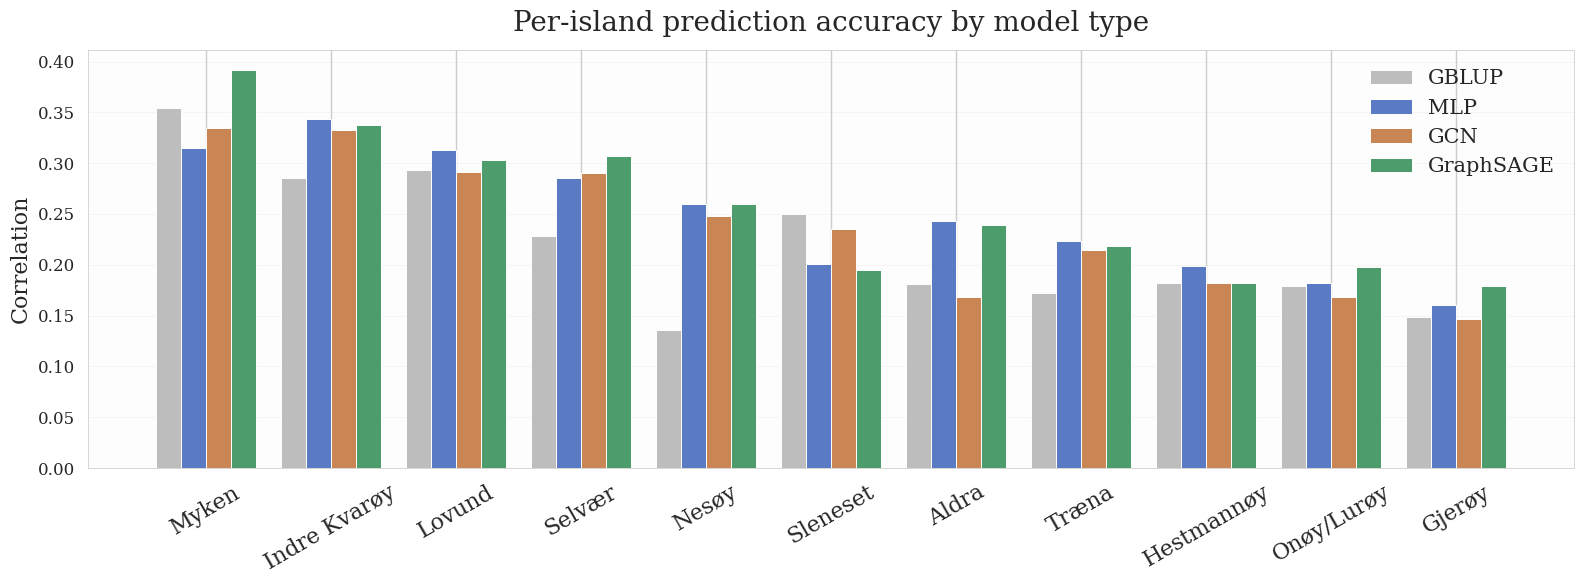


=== Best model variants selected ===


,model_type,model,count
0,GBLUP,gblup_aase,33
2,GCN,gcn_inductive,19
1,GCN,gcn,14
5,GraphSAGE,sage_inductive,13
3,GraphSAGE,ens_sage,10
4,GraphSAGE,sage,10
6,MLP,mlp,20
7,MLP,mlp_ens,13


In [502]:
# Per-island accuracy by model (4 boxes per island: GBLUP, MLP, GCN, GraphSAGE)
# Average over phenotypes, select best variant for each model type
if not loio_island_df.empty:
    # Fix encoding issues in island names
    loio_island_df_copy3 = loio_island_df.copy()
    loio_island_df_copy3["island"] = loio_island_df_copy3["island"].str.replace("Ã¸", "ø").str.replace("Ã¦", "æ")
    
    # Standardize Onøy/Lurøy variations
    loio_island_df_copy3.loc[loio_island_df_copy3["island"].str.contains("Onøy", case=False, na=False), "island"] = "Onøy/Lurøy"
    
    # Determine model type from model key
    def get_model_type(model_key):
        model_key_lower = model_key.lower()
        if "gblup" in model_key_lower:
            return "GBLUP"
        elif "mlp" in model_key_lower:
            return "MLP"
        elif "gcn" in model_key_lower:
            return "GCN"
        elif "sage" in model_key_lower:
            return "GraphSAGE"
        else:
            return "Other"
    
    loio_island_df_copy3["model_type"] = loio_island_df_copy3["model"].apply(get_model_type)
    
    # For each island × phenotype × model_type, select the best model variant
    best_variants = []
    for (island, phenotype, model_type), group in loio_island_df_copy3.groupby(["island", "phenotype", "model_type"]):
        best_idx = group["pearson_r"].idxmax()
        best_variants.append(group.loc[best_idx])
    
    best_df = pd.DataFrame(best_variants)
    
    # Now average over phenotypes for each island × model_type
    island_model_avg = best_df.groupby(["island", "model_type"])["pearson_r"].mean().reset_index()
    
    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(16, 6))
        
        # Order islands by mean correlation across all models
        island_order = island_model_avg.groupby("island")["pearson_r"].mean().sort_values(ascending=False).index.tolist()
        
        # Order models
        model_order = ["GBLUP", "MLP", "GCN", "GraphSAGE"]
        # Use MODEL_COLORS palette
        palette = [MODEL_COLORS[model] for model in model_order]
        
        # Pivot data for grouped bar plot
        plot_data = island_model_avg.pivot(index="island", columns="model_type", values="pearson_r")
        plot_data = plot_data.reindex(island_order)[model_order]
        
        # Create grouped bar plot
        x = np.arange(len(island_order))
        width = 0.2
        
        for i, model in enumerate(model_order):
            if model in plot_data.columns:
                offset = width * (i - 1.5)
                ax.bar(x + offset, plot_data[model], width, label=model, color=palette[i], edgecolor='white', linewidth=0.7)
        
        ax.set_ylabel("Correlation", fontsize=16)
        ax.set_title("Per-island prediction accuracy by model type", fontsize=20)
        ax.set_facecolor("#fdfdfd")
        ax.grid(True, axis="y", linewidth=0.4, alpha=0.3, zorder=0)
        ax.legend(title="", frameon=False, fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels(island_order, rotation=30, fontsize=16)
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.6)
            spine.set_color("#d0d0d0")
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "per_island_accuracy_by_model.pdf", dpi=150, bbox_inches="tight")
        print(f"Saved figure to {FIGURES_DIR / 'per_island_accuracy_by_model.pdf'}")
        plt.show()
    
    # Show which variants were selected for each model type
    print("\n=== Best model variants selected ===")
    variant_counts = best_df.groupby(["model_type", "model"]).size().reset_index(name="count")
    variant_counts = variant_counts.sort_values(["model_type", "count"], ascending=[True, False])
    display(variant_counts)

Saved figure to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures\per_island_accuracy_dotplot.pdf


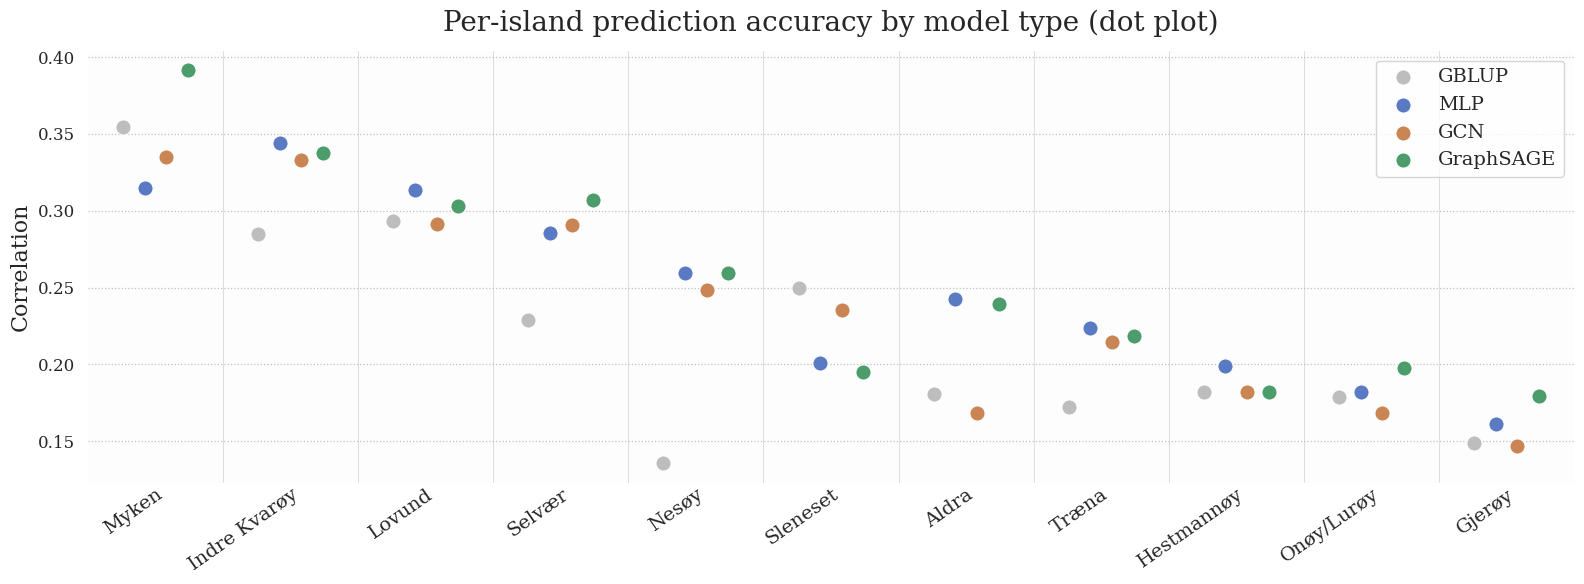

In [543]:
# Alternative 1: DOT PLOT (points instead of bars)
# Per-island accuracy by model - using scatter/dot plot
if not loio_island_df.empty:
    # Fix encoding issues in island names
    loio_island_df_copy_dot = loio_island_df.copy()
    loio_island_df_copy_dot["island"] = loio_island_df_copy_dot["island"].str.replace("Ã¸", "ø").str.replace("Ã¦", "æ")
    loio_island_df_copy_dot.loc[loio_island_df_copy_dot["island"].str.contains("Onøy", case=False, na=False), "island"] = "Onøy/Lurøy"
    
    def get_model_type(model_key):
        model_key_lower = model_key.lower()
        if "gblup" in model_key_lower:
            return "GBLUP"
        elif "mlp" in model_key_lower:
            return "MLP"
        elif "gcn" in model_key_lower:
            return "GCN"
        elif "sage" in model_key_lower:
            return "GraphSAGE"
        else:
            return "Other"
    
    loio_island_df_copy_dot["model_type"] = loio_island_df_copy_dot["model"].apply(get_model_type)
    
    # For each island × phenotype × model_type, select the best model variant
    best_variants = []
    for (island, phenotype, model_type), group in loio_island_df_copy_dot.groupby(["island", "phenotype", "model_type"]):
        best_idx = group["pearson_r"].idxmax()
        best_variants.append(group.loc[best_idx])
    
    best_df_dot = pd.DataFrame(best_variants)
    island_model_avg_dot = best_df_dot.groupby(["island", "model_type"])["pearson_r"].mean().reset_index()
    
    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(16, 6))
        
        # Order islands by mean correlation across all models
        island_order = island_model_avg_dot.groupby("island")["pearson_r"].mean().sort_values(ascending=False).index.tolist()
        
        model_order = ["GBLUP", "MLP", "GCN", "GraphSAGE"]
        
        # Pivot data
        plot_data = island_model_avg_dot.pivot(index="island", columns="model_type", values="pearson_r")
        plot_data = plot_data.reindex(island_order)[model_order]
        
        # Create dot plot with offset for each model
        x = np.arange(len(island_order))
        offsets = [-0.24, -0.08, 0.08, 0.24]  # Spread models horizontally
        
        for i, model in enumerate(model_order):
            if model in plot_data.columns:
                ax.scatter(
                    x + offsets[i], 
                    plot_data[model], 
                    s=120,  # Point size
                    c=MODEL_COLORS[model], 
                    label=model, 
                    edgecolors='white',
                    linewidths=0.8,
                    zorder=3,
                    marker='o'
                )
        
        ax.set_ylabel("Correlation", fontsize=16)
        ax.set_title("Per-island prediction accuracy by model type (dot plot)", fontsize=20)
        ax.set_facecolor("#fdfdfd")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9, zorder=0)
        
        # Add vertical grid lines between islands (at x + 0.5 positions)
        for xi in range(len(island_order) - 1):
            ax.axvline(x=xi + 0.5, color="#d9d9d9", linestyle="-", linewidth=0.6, zorder=0)
        
        ax.legend(title="", frameon=True, fontsize=14, loc="best")
        ax.set_xticks(x)
        ax.set_xticklabels(island_order, rotation=35, ha='right', rotation_mode='anchor', fontsize=14)
        ax.set_xlim(-0.5, len(island_order) - 0.5)
        ax.grid(False, axis='x')
        
        # Add tick marks above each island and move labels closer
        ax.tick_params(axis='x', direction='in', length=6, width=1.2, color='#555555', pad=2)
        
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "per_island_accuracy_dotplot.pdf", dpi=300, bbox_inches="tight")
        print(f"Saved figure to {FIGURES_DIR / 'per_island_accuracy_dotplot.pdf'}")
        plt.show()

Saved figure to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures\per_island_accuracy_hbar.pdf


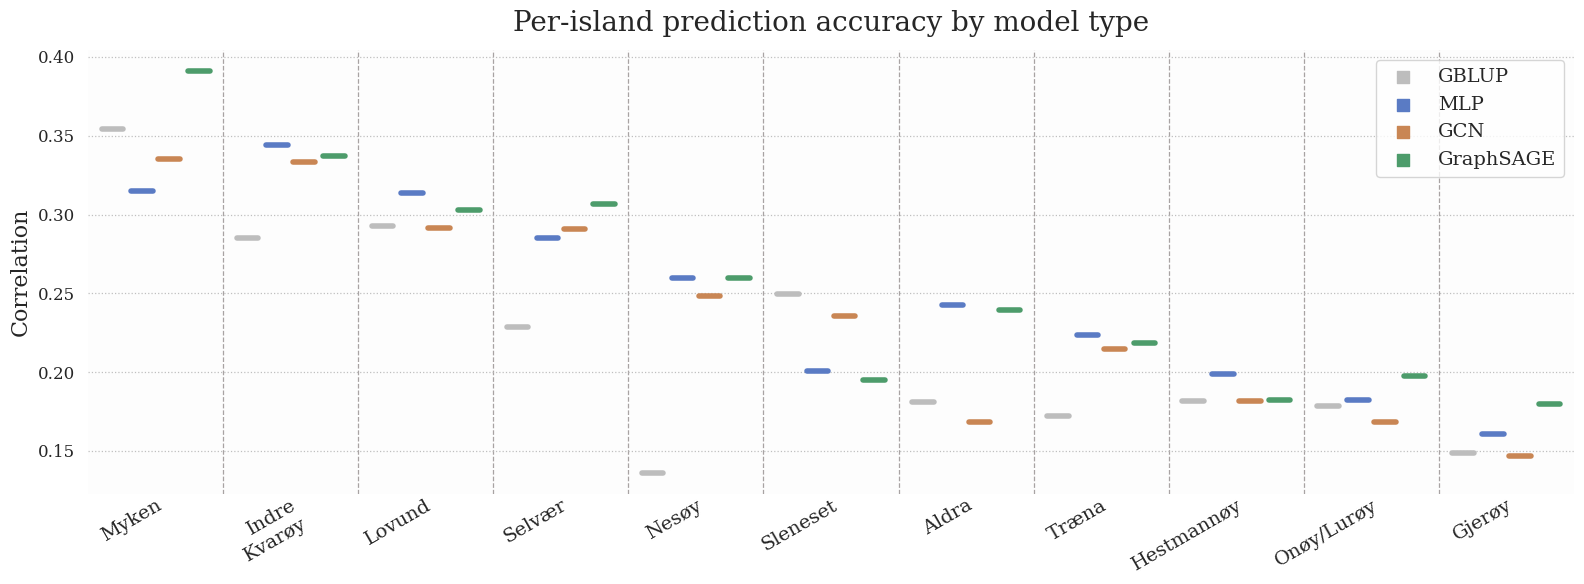

In [548]:
# Alternative 2: HORIZONTAL BAR PLOT (narrow horizontal lines at each value)
# Per-island accuracy by model - using short horizontal bars (like a dash/tick mark)
# Set show_center_point=True to add a small dot in the middle of each bar

show_center_point = False  # Toggle this to add/remove center points

if not loio_island_df.empty:
    # Fix encoding issues in island names
    loio_island_df_copy_hbar = loio_island_df.copy()
    loio_island_df_copy_hbar["island"] = loio_island_df_copy_hbar["island"].str.replace("Ã¸", "ø").str.replace("Ã¦", "æ")
    loio_island_df_copy_hbar.loc[loio_island_df_copy_hbar["island"].str.contains("Onøy", case=False, na=False), "island"] = "Onøy/Lurøy"
    
    def get_model_type(model_key):
        model_key_lower = model_key.lower()
        if "gblup" in model_key_lower:
            return "GBLUP"
        elif "mlp" in model_key_lower:
            return "MLP"
        elif "gcn" in model_key_lower:
            return "GCN"
        elif "sage" in model_key_lower:
            return "GraphSAGE"
        else:
            return "Other"
    
    loio_island_df_copy_hbar["model_type"] = loio_island_df_copy_hbar["model"].apply(get_model_type)
    
    # For each island × phenotype × model_type, select the best model variant
    best_variants = []
    for (island, phenotype, model_type), group in loio_island_df_copy_hbar.groupby(["island", "phenotype", "model_type"]):
        best_idx = group["pearson_r"].idxmax()
        best_variants.append(group.loc[best_idx])
    
    best_df_hbar = pd.DataFrame(best_variants)
    island_model_avg_hbar = best_df_hbar.groupby(["island", "model_type"])["pearson_r"].mean().reset_index()
    
    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(16, 6))
        
        # Order islands by mean correlation across all models
        island_order = island_model_avg_hbar.groupby("island")["pearson_r"].mean().sort_values(ascending=False).index.tolist()
        
        model_order = ["GBLUP", "MLP", "GCN", "GraphSAGE"]
        
        # Pivot data
        plot_data = island_model_avg_hbar.pivot(index="island", columns="model_type", values="pearson_r")
        plot_data = plot_data.reindex(island_order)[model_order]
        
        # Create horizontal bar plot with offset for each model
        x = np.arange(len(island_order))
        offsets = [-0.32, -0.1, 0.1, 0.32]  # Spread models horizontally
        bar_half_width = 0.08  # Half-width of each horizontal bar
        
        for i, model in enumerate(model_order):
            if model in plot_data.columns:
                x_pos = x + offsets[i]
                y_vals = plot_data[model].values
                
                # Draw narrow horizontal bars (short horizontal lines at each y value)
                for xi, yi in zip(x_pos, y_vals):
                    ax.plot(
                        [xi - bar_half_width, xi + bar_half_width],  # x range (horizontal bar)
                        [yi, yi],  # y stays constant
                        color=MODEL_COLORS[model], 
                        linewidth=4,  # Thickness of the bar
                        solid_capstyle='round',
                        zorder=2
                    )
                
                # Optionally add center points
                if show_center_point:
                    ax.scatter(
                        x_pos, 
                        y_vals, 
                        s=25,  # Small point size
                        c='white',  # White center
                        edgecolors=MODEL_COLORS[model],
                        linewidths=1.2,
                        zorder=3,
                        marker='o'
                    )
                
                # Add invisible scatter for legend
                ax.scatter([], [], s=80, c=MODEL_COLORS[model], label=model, marker='s')
        
        ax.set_ylabel("Correlation", fontsize=16)
        title_suffix = " (with points)" if show_center_point else ""
        ax.set_title(f"Per-island prediction accuracy by model type{title_suffix}", fontsize=20)
        ax.set_facecolor("#fdfdfd")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9, zorder=0)
        
        # Add vertical grid lines between islands (at x + 0.5 positions)
        for xi in range(len(island_order) - 1):
            ax.axvline(x=xi + 0.5, color="#a8a3a3", linestyle="--", linewidth=0.9, zorder=0)

        # if island name has spaces, replace with newline for better display
        island_order = [name.replace(" ", "\n") for name in island_order]
        
        ax.legend(title="", frameon=True, fontsize=14, loc="best")
        ax.set_xticks(x)
        ax.set_xticklabels(island_order, rotation=30, ha='right', rotation_mode='anchor', fontsize=14)
        ax.set_xlim(-0.5, len(island_order) - 0.5)
        
        # Add tick marks above each island and move labels closer
        ax.tick_params(axis='x', direction='in', length=6, width=1.2, color='#555555', pad=2)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # turn off vertical grid lines
        ax.grid(False, axis="x")
        
        plt.tight_layout()
        filename = "per_island_accuracy_hbar_points.pdf" if show_center_point else "per_island_accuracy_hbar.pdf"
        plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {FIGURES_DIR / filename}")
        plt.show()

In [ ]:
# Export Figure 2 data: Per-island prediction accuracy
if not loio_island_df.empty:
    # Fix encoding issues in island names
    loio_export = loio_island_df.copy()
    loio_export["island"] = loio_export["island"].str.replace("Ã¸", "ø").str.replace("Ã¦", "æ")
    loio_export.loc[loio_export["island"].str.contains("Onøy", case=False, na=False), "island"] = "Onøy/Lurøy"
    
    # Determine model type from model key
    def get_model_type(model_key):
        model_key_lower = model_key.lower()
        if "gblup" in model_key_lower:
            return "GBLUP"
        elif "mlp" in model_key_lower:
            return "MLP"
        elif "gcn" in model_key_lower:
            return "GCN"
        elif "sage" in model_key_lower:
            return "GraphSAGE"
        else:
            return "Other"
    
    loio_export["model_type"] = loio_export["model"].apply(get_model_type)
    
    # Export raw data (all model variants, all phenotypes, all islands)
    raw_export = loio_export[['island', 'phenotype', 'model', 'model_type', 'pearson_r']].copy()
    raw_export = raw_export.sort_values(['island', 'phenotype', 'model_type'])
    
    raw_path = STATISTICS_DIR / "figure2_per_island_raw_data.csv"
    raw_export.to_csv(raw_path, index=False, float_format='%.4f')
    print(f"Saved raw per-island data to {raw_path}")
    
    # Export the aggregated data used in the figure (best variant per model type, averaged over phenotypes)
    best_variants = []
    for (island, phenotype, model_type), group in loio_export.groupby(["island", "phenotype", "model_type"]):
        best_idx = group["pearson_r"].idxmax()
        best_variants.append(group.loc[best_idx])
    
    best_df = pd.DataFrame(best_variants)
    
    # Average over phenotypes for each island × model_type
    island_model_avg = best_df.groupby(["island", "model_type"])["pearson_r"].agg(['mean', 'std', 'count']).reset_index()
    island_model_avg.columns = ['island', 'model_type', 'mean_correlation', 'std_correlation', 'n_phenotypes']
    
    # Pivot to wide format (one row per island)
    pivot_data = island_model_avg.pivot(index='island', columns='model_type', values='mean_correlation')
    pivot_data = pivot_data.reset_index()
    
    # Add overall mean per island
    model_cols = [col for col in pivot_data.columns if col != 'island']
    pivot_data['overall_mean'] = pivot_data[model_cols].mean(axis=1)
    
    # Sort by overall mean (descending)
    pivot_data = pivot_data.sort_values('overall_mean', ascending=False)
    
    pivot_path = STATISTICS_DIR / "figure2_per_island_by_model.csv"
    pivot_data.to_csv(pivot_path, index=False, float_format='%.4f')
    print(f"Saved per-island averages by model to {pivot_path}")
    display(pivot_data)
    
    # Also export the long format version
    long_path = STATISTICS_DIR / "figure2_per_island_by_model_long.csv"
    island_model_avg.to_csv(long_path, index=False, float_format='%.4f')
    print(f"Saved per-island averages (long format) to {long_path}")
else:
    print("No LOIO island data available for export.")

Saved raw per-island data to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figure2_per_island_raw_data.csv
Saved per-island averages by model to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figure2_per_island_by_model.csv


model_type,island,GBLUP,GCN,GraphSAGE,MLP,overall_mean
5,Myken,0.354233,0.334927,0.391319,0.314616,0.348774
3,Indre Kvarøy,0.285000,0.332997,0.337377,0.343819,0.324799
4,Lovund,0.293000,0.291149,0.302798,0.313414,0.300090
8,Selvær,0.228600,0.290489,0.306886,0.285391,0.277841
6,Nesøy,0.135700,0.248361,0.259500,0.259506,0.225767
9,Sleneset,0.249633,0.235297,0.194937,0.200835,0.220176
0,Aldra,0.180833,0.168223,0.239134,0.242841,0.207758
10,Træna,0.172000,0.214414,0.218272,0.223552,0.207059
2,Hestmannøy,0.181933,0.181791,0.181997,0.198955,0.186169
7,Onøy/Lurøy,0.178733,0.168346,0.197601,0.181994,0.181668


Saved per-island averages (long format) to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figure2_per_island_by_model_long.csv


In [ ]:
# Export Figure 1 data: Graph construction statistics
if not graph_summary.empty:
    # Prepare the data with relevant columns
    graph_stats_export = graph_summary[[
        'model_label', 'phenotype_label', 'scenario', 
        'fold_id', 'threshold', 'mean_degree', 'intra_island_fraction'
    ]].copy()
    
    # Sort for readability
    graph_stats_export = graph_stats_export.sort_values(
        ['phenotype_label', 'model_label', 'scenario', 'fold_id']
    )
    
    # Save to CSV
    csv_path = STATISTICS_DIR / "figure1_graph_construction_statistics.csv"
    graph_stats_export.to_csv(csv_path, index=False, float_format='%.4f')
    print(f"Saved graph construction statistics to {csv_path}")
    
    # Also create a summary statistics CSV (mean, std, min, max for each metric)
    summary_stats = []
    for metric in ['threshold', 'mean_degree', 'intra_island_fraction']:
        for pheno in ["Tarsus length", "Body mass", "Wing length"]:
            for model in ["GCN", "GraphSAGE"]:
                subset = graph_summary[
                    (graph_summary['phenotype_label'] == pheno) & 
                    (graph_summary['model_label'] == model)
                ][metric].dropna()
                
                if len(subset) > 0:
                    summary_stats.append({
                        'metric': metric,
                        'phenotype': pheno,
                        'model': model,
                        'mean': subset.mean(),
                        'std': subset.std(),
                        'min': subset.min(),
                        'q25': subset.quantile(0.25),
                        'median': subset.median(),
                        'q75': subset.quantile(0.75),
                        'max': subset.max(),
                        'count': len(subset)
                    })
    
    summary_df = pd.DataFrame(summary_stats)
    summary_path = STATISTICS_DIR / "figure1_graph_construction_summary.csv"
    summary_df.to_csv(summary_path, index=False, float_format='%.4f')
    print(f"Saved graph construction summary statistics to {summary_path}")
    display(summary_df)
else:
    print("No graph summary data available for export.")

Saved graph construction statistics to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figure1_graph_construction_statistics.csv
Saved graph construction summary statistics to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figure1_graph_construction_summary.csv


,metric,phenotype,model,mean,std,min,q25,median,q75,max,count
0,threshold,Tarsus length,GCN,0.508358,0.125728,0.333160,0.395821,0.503296,0.583109,0.814558,24
1,threshold,Tarsus length,GraphSAGE,0.581429,0.189822,0.311532,0.416714,0.532031,0.806781,0.899918,30
2,threshold,Body mass,GCN,0.747669,0.106946,0.531283,0.660111,0.776485,0.831479,0.899678,30
3,threshold,Body mass,GraphSAGE,0.589264,0.150105,0.371416,0.461059,0.571694,0.685455,0.894273,22
4,threshold,Wing length,GCN,0.724098,0.122647,0.286569,0.643556,0.731298,0.822845,0.884858,31
5,threshold,Wing length,GraphSAGE,0.663503,0.200019,0.252275,0.616812,0.752094,0.810396,0.888368,37
6,mean_degree,Tarsus length,GCN,0.481238,0.411361,0.004658,0.145850,0.374746,0.922949,1.666346,32
7,mean_degree,Tarsus length,GraphSAGE,0.576173,0.557311,0.000000,0.052795,0.418794,0.861042,2.245221,42
8,mean_degree,Body mass,GCN,0.112418,0.261056,0.000000,0.000343,0.004637,0.041861,0.981563,32
9,mean_degree,Body mass,GraphSAGE,0.587585,0.465436,0.000000,0.120864,0.669935,0.933874,2.234589,42


## Export data to CSV files

## SNP Selection Trends Analysis

In [ ]:
# Load graph_summary.csv for SNP selection analysis
snp_df = pd.read_csv(STATISTICS_DIR / "graph_summary.csv")

# Map model types to labels
snp_df["model_label"] = snp_df["model_type"].map({"gcn": "GCN", "graphsage": "GraphSAGE", "mlp": "MLP"})
snp_df["scenario_label"] = snp_df["scenario"].map({"across": "Across", "within": "Within"})
snp_df["trait_label"] = snp_df["trait"].map(PHENOTYPE_LABELS)

print(f"Loaded {len(snp_df)} records from graph_summary.csv")
print(f"Models: {snp_df['model_label'].unique().tolist()}")
print(f"Scenarios: {snp_df['scenario_label'].unique().tolist()}")

Loaded 285 records from graph_summary.csv
Models: ['GCN', 'MLP', 'GraphSAGE']
Scenarios: ['Within', 'Across']


Saved figure to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures\snp_selection_trends_2x2.pdf


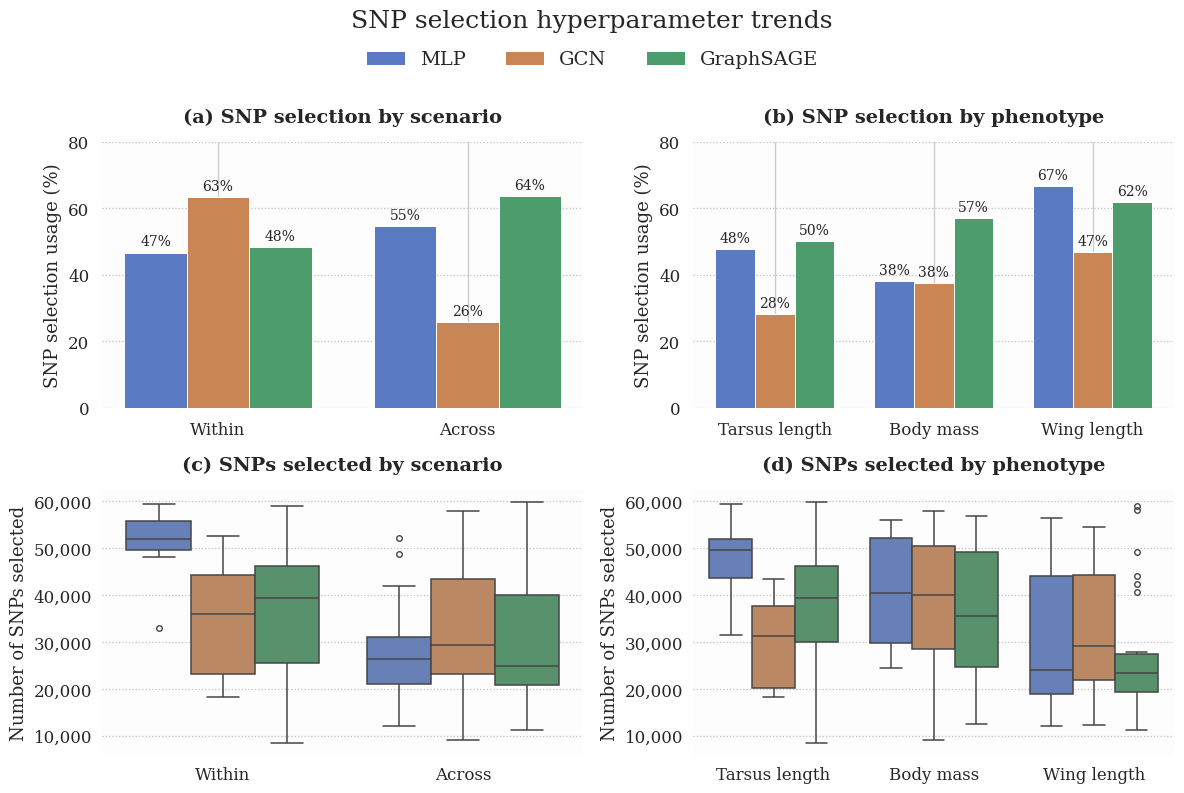


=== SNP selection usage summary ===
scenario_label  model_label
Across          GCN            25.8
                GraphSAGE      63.6
                MLP            54.5
Within          GCN            63.3
                GraphSAGE      48.3
                MLP            46.7
Name: use_snp_selection, dtype: float64

=== Number of SNPs summary (when selection enabled) ===
                               mean      std  count
scenario_label model_label                         
Across         GCN          32883.0  15373.0     17
               GraphSAGE    30966.0  14018.0     42
               MLP          27812.0  11453.0     18
Within         GCN          34217.0  11414.0     19
               GraphSAGE    37651.0  13336.0     29
               MLP          51804.0   6472.0     14

=== Number of SNPs summary by phenotype (when selection enabled) ===
                              mean      std  count
trait_label   model_label                         
Body mass     GCN          38496.0

In [508]:
# Figure: SNP Selection Trends (2x3 figure)
# Include all models (MLP, GCN, GraphSAGE)

# Calculate proportions for bar plots - all models
all_models_df = snp_df.copy()
snp_by_scenario_model = all_models_df.groupby(["scenario_label", "model_label"])["use_snp_selection"].mean() * 100
snp_pivot = snp_by_scenario_model.unstack()

snp_by_trait_model = all_models_df.groupby(["trait_label", "model_label"])["use_snp_selection"].mean() * 100
snp_trait_pivot = snp_by_trait_model.unstack()
trait_order = ["Tarsus length", "Body mass", "Wing length"]
snp_trait_pivot = snp_trait_pivot.reindex(trait_order)

# Filter for models with SNP selection enabled for boxplots
snp_selected = all_models_df[all_models_df["use_snp_selection"] == True].copy()

with plt.rc_context(PLOT_STYLE):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    model_order = ["MLP", "GCN", "GraphSAGE"]
    model_palette = {m: MODEL_COLORS[m] for m in model_order}
    width = 0.25  # Narrower bars for 3 models
    
    # Order: Within first, then Across
    scenario_order = ["Within", "Across"]
    snp_pivot = snp_pivot.reindex(scenario_order)
    
    # ─────────────────────── Panel (a): SNP selection % by scenario ───────────────────────
    ax1 = axes[0, 0]
    x = np.arange(len(snp_pivot.index))
    
    for i, model in enumerate(model_order):
        offset = width * (i - 1)
        bars = ax1.bar(x + offset, snp_pivot[model], width, 
                       label=model, color=model_palette[model], 
                       edgecolor='white', linewidth=0.7)
        for bar in bars:
            height = bar.get_height()
            ax1.annotate(f'{height:.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)
    
    ax1.set_ylabel("SNP selection usage (%)", fontsize=13)
    ax1.set_xlabel("", fontsize=13)
    ax1.set_title("(a) SNP selection by scenario", fontsize=14, fontweight="semibold")
    ax1.set_xticks(x)
    ax1.set_xticklabels(snp_pivot.index, fontsize=12)
    ax1.set_ylim(0, 80)
    ax1.set_facecolor("#fdfdfd")
    ax1.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    # ─────────────────────── Panel (b): SNP selection % by phenotype ───────────────────────
    ax2 = axes[0, 1]
    x2 = np.arange(len(snp_trait_pivot.index))
    
    for i, model in enumerate(model_order):
        offset = width * (i - 1)
        bars = ax2.bar(x2 + offset, snp_trait_pivot[model], width, 
                       label=model, color=model_palette[model], 
                       edgecolor='white', linewidth=0.7)
        for bar in bars:
            height = bar.get_height()
            ax2.annotate(f'{height:.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)
    
    ax2.set_ylabel("SNP selection usage (%)", fontsize=13)
    ax2.set_xlabel("", fontsize=13)
    ax2.set_title("(b) SNP selection by phenotype", fontsize=14, fontweight="semibold")
    ax2.set_xticks(x2)
    ax2.set_xticklabels(snp_trait_pivot.index, fontsize=12)
    ax2.set_ylim(0, 80)
    ax2.set_facecolor("#fdfdfd")
    ax2.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    
    # ─────────────────────── Panel (c): num_snps by scenario ───────────────────────
    ax3 = axes[1, 0]
    
    sns.boxplot(
        data=snp_selected,
        x="scenario_label",
        y="num_snps",
        hue="model_label",
        hue_order=model_order,
        order=scenario_order,
        palette=model_palette,
        ax=ax3,
        linewidth=1.1,
        fliersize=4.0,
    )
    
    ax3.set_ylabel("Number of SNPs selected", fontsize=13)
    ax3.set_xlabel("", fontsize=13)
    ax3.set_title("(c) SNPs selected by scenario", fontsize=14, fontweight="semibold")
    ax3.set_facecolor("#fdfdfd")
    ax3.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
    ax3.tick_params(axis="x", labelsize=12, length=4)
    ax3.tick_params(axis="y", labelsize=12, length=4)
    if ax3.legend_:
        ax3.legend_.remove()
    for spine in ax3.spines.values():
        spine.set_visible(False)
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # ─────────────────────── Panel (d): num_snps by phenotype ───────────────────────
    ax4 = axes[1, 1]
    
    sns.boxplot(
        data=snp_selected,
        x="trait_label",
        y="num_snps",
        hue="model_label",
        hue_order=model_order,
        order=trait_order,
        palette=model_palette,
        ax=ax4,
        linewidth=1.1,
        fliersize=4.0,
    )
    
    ax4.set_ylabel("Number of SNPs selected", fontsize=13)
    ax4.set_xlabel("", fontsize=13)
    ax4.set_title("(d) SNPs selected by phenotype", fontsize=14, fontweight="semibold")
    ax4.set_facecolor("#fdfdfd")
    ax4.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
    ax4.tick_params(axis="x", labelsize=12, length=4)
    ax4.tick_params(axis="y", labelsize=12, length=4)
    if ax4.legend_:
        ax4.legend_.remove()
    for spine in ax4.spines.values():
        spine.set_visible(False)
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Add shared legend below title
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=3,
        frameon=False,
        fontsize=14,
    )
    
    fig.suptitle("SNP selection hyperparameter trends", fontsize=18, y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(FIGURES_DIR / "snp_selection_trends_2x2.pdf", dpi=300, bbox_inches="tight")
    print(f"Saved figure to {FIGURES_DIR / 'snp_selection_trends_2x2.pdf'}")
    plt.show()

# Print summary statistics
print("\n=== SNP selection usage summary ===")
print(all_models_df.groupby(["scenario_label", "model_label"])["use_snp_selection"].mean().round(3) * 100)
print("\n=== Number of SNPs summary (when selection enabled) ===")
print(snp_selected.groupby(["scenario_label", "model_label"])["num_snps"].agg(["mean", "std", "count"]).round(0))
print("\n=== Number of SNPs summary by phenotype (when selection enabled) ===")
print(snp_selected.groupby(["trait_label", "model_label"])["num_snps"].agg(["mean", "std", "count"]).round(0))

Loaded 255 records with learning mode info
Learning modes: ['Transductive', 'Inductive']
Counts by mode:
model_type  learning_mode
GCN         Inductive        33
            Transductive     63
GraphSAGE   Inductive        63
            Transductive     96
dtype: int64
Saved figure to c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\25H\Prosjekt\Project_thesis\figures\snp_selection_by_learning_mode.pdf


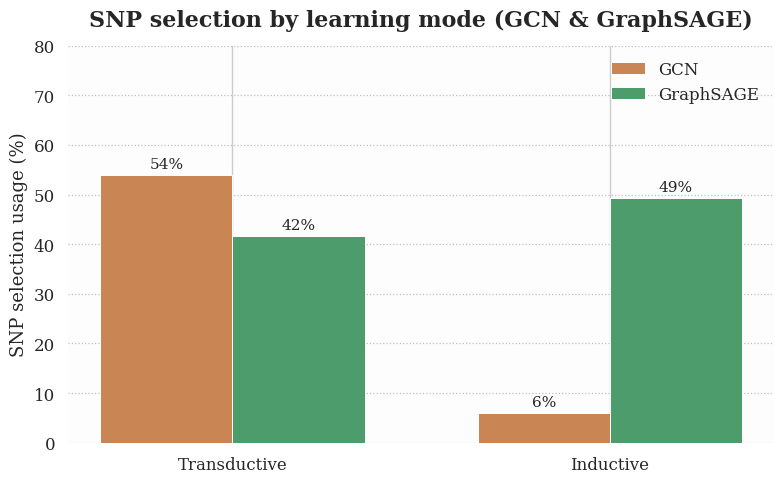


=== SNP selection by learning mode ===
                           mean  count
learning_mode model_type              
Inductive     GCN         0.061     33
              GraphSAGE   0.492     63
Transductive  GCN         0.540     63
              GraphSAGE   0.417     96


In [509]:
# Figure: SNP Selection by Learning Mode (Inductive vs Transductive) - GCN and GraphSAGE only
# Load data from nested CV JSONs to get inductive/transductive distinction

def load_snp_selection_with_mode(base_dir: Path) -> pd.DataFrame:
    """Load SNP selection data with inductive/transductive mode distinction."""
    rows = []
    for phenotype_dir in sorted(base_dir.glob("*")):
        if not phenotype_dir.is_dir():
            continue
        phenotype = phenotype_dir.name
        if phenotype not in PHENOTYPE_LABELS:
            continue
        for scenario in ("loio", "within"):
            scenario_dir = phenotype_dir / scenario
            if not scenario_dir.exists():
                continue
            for json_path in sorted(scenario_dir.glob("*.json")):
                model_key = json_path.stem.replace("_results", "")
                # Only GCN and GraphSAGE
                if "gcn" not in model_key and "sage" not in model_key:
                    continue
                
                # Determine model type and learning mode
                is_inductive = "inductive" in model_key.lower()
                if "gcn" in model_key:
                    model_type = "GCN"
                elif "sage" in model_key:
                    model_type = "GraphSAGE"
                else:
                    continue
                
                try:
                    with open(json_path) as fp:
                        data = json.load(fp)
                except Exception:
                    continue
                
                best_params = data.get("best_params_per_fold") or []
                for fold_idx, fold_info in enumerate(best_params):
                    params = fold_info.get("best_params") or fold_info.get("params") or {}
                    rows.append({
                        "phenotype": phenotype,
                        "phenotype_label": PHENOTYPE_LABELS.get(phenotype, phenotype),
                        "scenario": "Across" if scenario == "loio" else "Within",
                        "model_type": model_type,
                        "learning_mode": "Inductive" if is_inductive else "Transductive",
                        "use_snp_selection": params.get("use_snp_selection", False),
                        "num_snps": params.get("num_snps"),
                    })
    return pd.DataFrame(rows)

mode_df = load_snp_selection_with_mode(RESULTS_DIR)
print(f"Loaded {len(mode_df)} records with learning mode info")
print(f"Learning modes: {mode_df['learning_mode'].unique().tolist()}")
print(f"Counts by mode:\n{mode_df.groupby(['model_type', 'learning_mode']).size()}")

# Calculate SNP selection by learning mode
snp_by_mode = mode_df.groupby(["learning_mode", "model_type"])["use_snp_selection"].mean() * 100
snp_mode_pivot = snp_by_mode.unstack()

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    model_order = ["GCN", "GraphSAGE"]
    model_palette = {m: MODEL_COLORS[m] for m in model_order}
    width = 0.35
    
    # Order: Transductive first
    mode_order = ["Transductive", "Inductive"]
    snp_mode_pivot = snp_mode_pivot.reindex(mode_order)
    
    x = np.arange(len(snp_mode_pivot.index))
    
    for i, model in enumerate(model_order):
        offset = width * (i - 0.5)
        bars = ax.bar(x + offset, snp_mode_pivot[model], width, 
                      label=model, color=model_palette[model], 
                      edgecolor='white', linewidth=0.7)
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.0f}%',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=11)
    
    ax.set_ylabel("SNP selection usage (%)", fontsize=13)
    ax.set_xlabel("", fontsize=13)
    ax.set_title("SNP selection by learning mode (GCN & GraphSAGE)", fontsize=16, fontweight="semibold")
    ax.set_xticks(x)
    ax.set_xticklabels(snp_mode_pivot.index, fontsize=12)
    ax.set_ylim(0, 80)
    ax.set_facecolor("#fdfdfd")
    ax.grid(which="major", axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
    ax.legend(title="", frameon=False, fontsize=12, loc="upper right")
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "snp_selection_by_learning_mode.pdf", dpi=300, bbox_inches="tight")
    print(f"Saved figure to {FIGURES_DIR / 'snp_selection_by_learning_mode.pdf'}")
    plt.show()

# Print summary
print("\n=== SNP selection by learning mode ===")
print(mode_df.groupby(["learning_mode", "model_type"])["use_snp_selection"].agg(["mean", "count"]).round(3))